# Spectral functions in infinite geometries

For a crystal that is genuinely infinite (periodic, no boundary) in every direction, the
momentum-resolved spectral function $A(k_1,\omega)$ resolved along one reciprocal direction
$k_1$ but summed over the other, $k_2$, is ordinarily a Brillouin-zone integral

$$A(k_1,\omega) = \frac{1}{\pi}\int_0^1 dk_2\;\left[-\mathrm{Im}\,\mathrm{Tr}\,G(k_1,k_2,\omega)\right],
\qquad G(k)=\left[(\omega+i\delta)\mathbb{1}-H(k)\right]^{-1}.$$

`h.get_surface_kdos` obtains the *same* physical quantity for the bulk (its `db` output) with a
completely different, and in principle exact, technique that never performs that $k_2$ sum or
diagonalizes $H(k_1,k_2)$ at all: a real-space Green's-function renormalization
(decimation) iteration treats direction 2 as an infinite chain of unit cells (see the next
notebooks for the same machinery applied to a genuine, physical boundary/surface), converging to
the bulk-cell Green's function directly. Below, the decimation result is checked against the
explicit $k_2$-integral, on the same honeycomb lattice, and agrees to numerical precision.

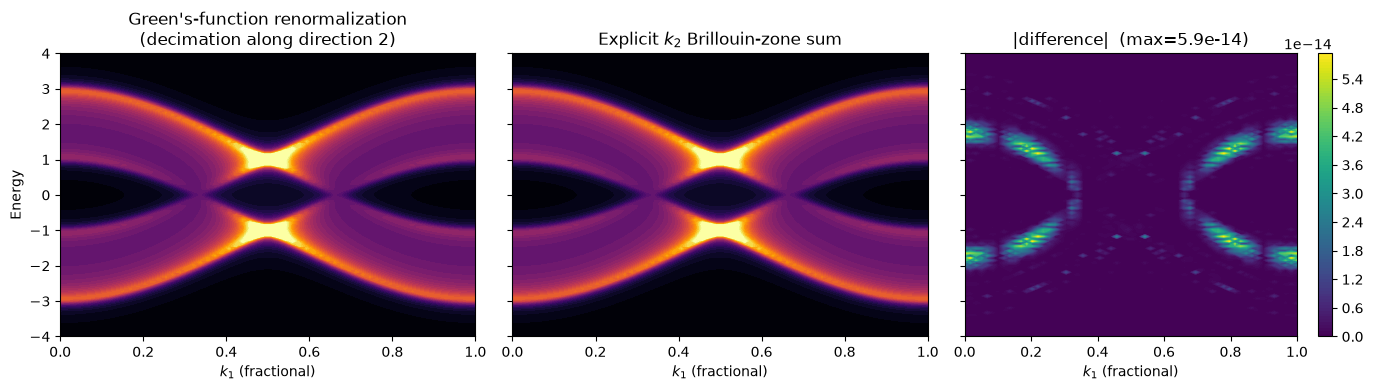

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
g = geometry.honeycomb_lattice()
h = g.get_hamiltonian(has_spin=False)

nk = 60
delta = 0.1
energies = np.linspace(-4,4,120)

# Green's-function renormalization (decimation) along direction 2: no k2 sum,
# no diagonalization -- db is the raw -Im Tr G trace, matching h.get_dos's own
# "Green"/"RG" mode convention of leaving the 1/pi normalization to the caller
k,e,ds,db = h.get_surface_kdos(delta=delta,nk=nk,energies=energies)
db_grid = (db/np.pi).reshape(nk,len(energies)).T

# cross-check: the same quantity the traditional way, by explicitly summing
# over k2 (a Brillouin-zone integral) of the fully periodic 2D Bloch Hamiltonian
hkgen = h.get_hk_gen()
n2 = 300
k2s = np.linspace(0.,1.,n2,endpoint=False)
k1s = np.linspace(0.,1.,nk)
d_ref = np.zeros((nk,len(energies)))
for i1,k1 in enumerate(k1s):
    for k2 in k2s:
        evals = np.linalg.eigvalsh(hkgen([k1,k2,0.]))
        d_ref[i1,:] += np.sum(delta/((energies[:,None]-evals[None,:])**2+delta**2),axis=1)
d_ref *= 1./(np.pi*n2)
d_ref = d_ref.T

fig,axs = plt.subplots(1,3,figsize=(14,4),sharey=True)
vmax = np.percentile(db_grid,99)
axs[0].contourf(k1s,energies,db_grid,levels=100,cmap="inferno",vmax=vmax)
axs[0].set_title("Green's-function renormalization\n(decimation along direction 2)")
axs[1].contourf(k1s,energies,d_ref,levels=100,cmap="inferno",vmax=vmax)
axs[1].set_title("Explicit $k_2$ Brillouin-zone sum")
diff = np.abs(db_grid-d_ref)
im = axs[2].contourf(k1s,energies,diff,levels=100,cmap="viridis")
axs[2].set_title(f"|difference|  (max={diff.max():.1e})")
plt.colorbar(im,ax=axs[2])
for ax in axs: ax.set_xlabel("$k_1$ (fractional)")
axs[0].set_ylabel("Energy")
plt.tight_layout()
plt.show()